In [1]:
# @title 1. Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             average_precision_score, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

# Ансамблевые модели
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Базовый классификатор для бэггинга
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style="ticks")
print("Библиотеки импортированы")

Библиотеки импортированы


In [3]:
# @title 2. Загрузка датасета Credit Card Fraud Detection
import urllib.request
import zipfile
import os

url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

try:
    df = pd.read_csv(url)
    print("Датасет Credit Card Fraud Detection загружен успешно!")
except Exception as e:
    print(f"Ошибка загрузки: {e}")

print(f"\nРазмер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()[:10]}...")

Датасет Credit Card Fraud Detection загружен успешно!

Размер датасета: (284807, 31)
Колонки: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']...


Размер датасета: (284807, 31)

Первые 5 строк:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Типы данных:
float64    30
int64       1
Name: count, dtype: int64

Статистика по признакам:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,...,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Пропущенные значения:
  Пропусков нет

Целевая переменная - Class (мошенничество):
Class
0    284315
1       492
Name: count, dtype: int64

0 (легальные): 284315 (99.83%)
1 (мошенничество): 492 (0.17%)


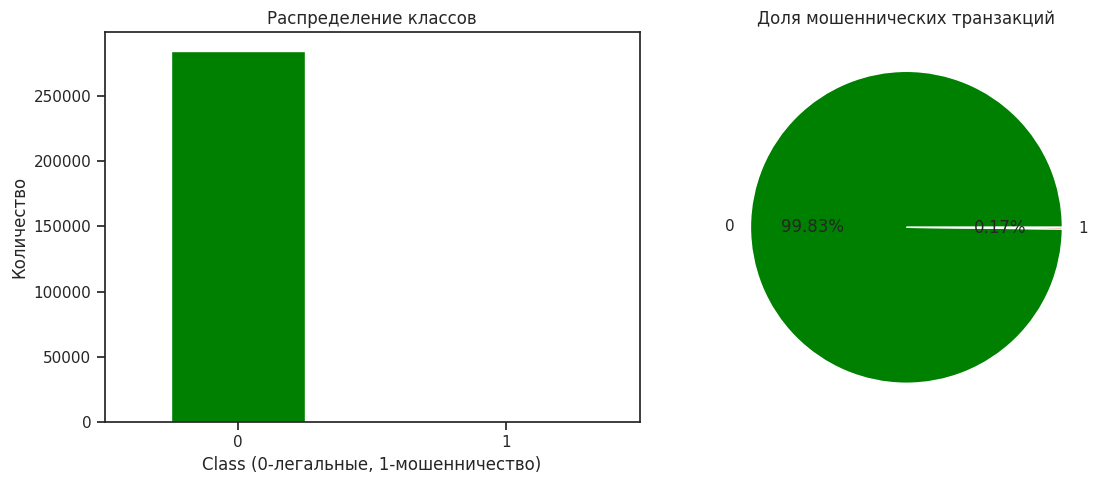


Анализ суммы транзакций:
  Легальные транзакции - средняя сумма: $88.29
  Мошеннические транзакции - средняя сумма: $122.21


In [4]:
# @title 3. Первичный анализ данных
print(f"Размер датасета: {df.shape}")

print("\nПервые 5 строк:")
display(df.head())

print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\nСтатистика по признакам:")
display(df.describe())

print("\nПропущенные значения:")
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
if len(null_counts) > 0:
    for col, count in null_counts.items():
        print(f"  {col}: {count} пропусков ({count/len(df)*100:.2f}%)")
else:
    print("  Пропусков нет")

# Целевая переменная
print("\nЦелевая переменная - Class (мошенничество):")
print(df['Class'].value_counts())
fraud_pct = df['Class'].sum() / len(df) * 100
print(f"\n0 (легальные): {sum(df['Class']==0)} ({100-fraud_pct:.2f}%)")
print(f"1 (мошенничество): {sum(df['Class']==1)} ({fraud_pct:.2f}%)")

# Визуализация дисбаланса классов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение классов')
plt.xlabel('Class (0-легальные, 1-мошенничество)')
plt.ylabel('Количество')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['Class'].value_counts().plot(kind='pie', autopct='%1.2f%%', colors=['green', 'red'])
plt.title('Доля мошеннических транзакций')
plt.ylabel('')

plt.tight_layout()
plt.show()

print("\nАнализ суммы транзакций:")
print(f"  Легальные транзакции - средняя сумма: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"  Мошеннические транзакции - средняя сумма: ${df[df['Class']==1]['Amount'].mean():.2f}")

In [5]:
# @title 4. Подготовка данных
df_clean = df.copy()
feature_cols = [col for col in df_clean.columns if col != 'Class']
X = df_clean[feature_cols].values
y = df_clean['Class'].values

print(f"Размер матрицы признаков X: {X.shape}")
print(f"Количество признаков: {len(feature_cols)}")

# Масштабирование признаков (используем RobustScaler из-за выбросов)
print("\nМасштабирование признаков...")
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("Статистика ПОСЛЕ масштабирования (первые 5 признаков):")
stats_df = pd.DataFrame({
    'Признак': feature_cols[:5],
    'Среднее': X_scaled[:, :5].mean(axis=0),
    'Стд_откл': X_scaled[:, :5].std(axis=0)
})
display(stats_df)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nРазделение данных:")
print(f"  Обучающая выборка: {X_train.shape[0]} строк ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Тестовая выборка: {X_test.shape[0]} строк ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nРаспределение классов в обучающей выборке:")
print(f"  0 (легальные): {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.2f}%)")
print(f"  1 (мошенничество): {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.2f}%)")

print(f"\nРаспределение классов в тестовой выборке:")
print(f"  0 (легальные): {sum(y_test==0)} ({sum(y_test==0)/len(y_test)*100:.2f}%)")
print(f"  1 (мошенничество): {sum(y_test==1)} ({sum(y_test==1)/len(y_test)*100:.2f}%)")

Размер матрицы признаков X: (284807, 30)
Количество признаков: 30

Масштабирование признаков...
Статистика ПОСЛЕ масштабирования (первые 5 признаков):


,Признак,Среднее,Стд_откл
0,Time,0.118914,0.557902
1,V1,-0.008099,0.875975
2,V2,-0.046700,1.177591
3,V3,-0.093789,0.790719
4,V4,0.012467,0.889374



Разделение данных:
  Обучающая выборка: 199364 строк (70.0%)
  Тестовая выборка: 85443 строк (30.0%)

Распределение классов в обучающей выборке:
  0 (легальные): 199020 (99.83%)
  1 (мошенничество): 344 (0.17%)

Распределение классов в тестовой выборке:
  0 (легальные): 85295 (99.83%)
  1 (мошенничество): 148 (0.17%)


1. Bagging - Bootstrap Aggregating
   -----------------------------------------
   Принцип работы:
   - Создается множество независимых моделей (базовых классификаторов)
   - Каждая модель обучается на случайной подвыборке исходных данных
     (выборка с возвращением - bootstrap)
   - Итоговое предсказание получается голосованием (для классификации)
     или усреднением (для регрессии)
   
   Преимущества:
   - Снижает дисперсию и предотвращает переобучение
   - Хорошо работает с нестабильными моделями (деревья решений)
   - Может быть распараллелен
   
   Недостатки:
   - Не улучшает смещение (bias)
   - Может быть вычислительно затратным
   
   Основные представители:
   - BaggingClassifier (с любым базовым классификатором)
   - RandomForestClassifier (бэггинг + случайный подбор признаков)
   - ExtraTreesClassifier (еще более случайный подбор порогов)

2. Random Forest
   -------------------------------
   Особенности:
   - Специализация бэггинга для деревьев решений
   - Дополнительная рандомизация: при каждом разбиении выбирается
     случайное подмножество признаков
   - Деревья строятся до полного "выращивания" (без обрезки)
   
   Преимущества:
   - Высокая точность
   - Устойчивость к переобучению
   - Возможность оценки важности признаков
   
   Гиперпараметры:
   - n_estimators: количество деревьев
   - max_features: количество признаков для разбиения
   - max_depth: максимальная глубина деревьев
   - min_samples_split: мин. объектов для разбиения узла

3. AdaBoost - Adaptive Boosting
   ----------------------------------------
   Принцип работы:
   - Модели обучаются последовательно
   - Каждая следующая модель фокусируется на ошибках предыдущих
   - Веса объектов корректируются: ошибочно классифицированные
     объекты получают больший вес
   - Итоговое предсказание - взвешенное голосование
   
   Преимущества:
   - Простота реализации
   - Хорошо работает с "слабыми" классификаторами (пни - деревья глубины 1)
   - Не требует настройки многих параметров
   
   Недостатки:
   - Чувствителен к шуму и выбросам
   - Последовательное обучение (сложно распараллелить)

4. Gradient Boosting
   -----------------------------------------
   Принцип работы:
   - Как и AdaBoost, обучает модели последовательно
   - Но вместо корректировки весов объектов, каждая следующая модель
     обучается на остатках (градиенте) предыдущей
   - Минимизирует функцию потерь градиентным спуском
   
   Преимущества:
   - Очень высокая точность
   - Гибкость (можно использовать различные функции потерь)
   - Устойчивость к переобучению (с правильной настройкой)
   
   Недостатки:
   - Много гиперпараметров
   - Требует осторожной настройки
   - Последовательное обучение

СРАВНЕНИЕ МЕТОДОВ:
-----------------
Характеристика     | Бэггинг | Случайный лес | AdaBoost | Град. бустинг
------------------|---------|---------------|----------|---------------
Снижение дисперсии | Высокое | Очень высокое | Среднее  | Среднее
Снижение смещения  | Низкое  | Низкое        | Высокое  | Высокое
Устойчивость к шуму| Высокая | Высокая       | Низкая   | Средняя
Скорость обучения | Быстрая | Средняя       | Быстрая  | Медленная
Параллелизация    | Да      | Да            | Нет      | Нет
Интерпретируемость| Низкая  | Средняя       | Низкая   | Низкая

Для задачи обнаружения мошенничества (сильный дисбаланс классов)
особенно важны метрики Precision (точность) и Recall (полнота),
а также ROC-AUC и Average Precision.

In [6]:
# @title 5. Обучение ансамблевых моделей
# Для учета дисбаланса классов вычисляем веса
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print(f"Веса классов: {class_weight_dict}")

# Базовый классификатор для бэггинга (дерево решений)
base_estimator = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

# 1. BaggingClassifier (бэггинг)
bagging_model = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bagging_model.fit(X_train, y_train)
print("  BaggingClassifier обучен")

# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("  RandomForest обучен")

# 3. AdaBoost
# Для AdaBoost используем деревья малой глубины
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
    n_estimators=100,
    learning_rate=1.0,
    algorithm='SAMME',
    random_state=42
)
ada_model.fit(X_train, y_train)
print("  AdaBoost обучен")

# 4. Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
print("  GradientBoosting обучен")

models = {
    'Bagging': bagging_model,
    'Random Forest': rf_model,
    'AdaBoost': ada_model,
    'Gradient Boosting': gb_model
}

Веса классов: {np.int64(0): np.float64(0.5008642347502763), np.int64(1): np.float64(289.7732558139535)}
  BaggingClassifier обучен
  RandomForest обучен
  AdaBoost обучен
  GradientBoosting обучен


In [7]:
# @title 6. Оценка качества моделей
results = []

for name, model in models.items():
    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        'Модель': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

# Сравнительная таблица
results_df = pd.DataFrame(results)
display(results_df.round(4))


Bagging:
  Accuracy:  0.9945
  Precision: 0.2128
  Recall:    0.8108
  F1-score:  0.3371
  ROC-AUC:   0.9572

Random Forest:
  Accuracy:  0.9993
  Precision: 0.8201
  Recall:    0.7703
  F1-score:  0.7944
  ROC-AUC:   0.9680

AdaBoost:
  Accuracy:  0.9706
  Precision: 0.0475
  Recall:    0.8378
  F1-score:  0.0899
  ROC-AUC:   0.9385

Gradient Boosting:
  Accuracy:  0.9984
  Precision: 0.6111
  Recall:    0.2230
  F1-score:  0.3267
  ROC-AUC:   0.3750


,Модель,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Bagging,0.9945,0.2128,0.8108,0.3371,0.9572
1,Random Forest,0.9993,0.8201,0.7703,0.7944,0.9680
2,AdaBoost,0.9706,0.0475,0.8378,0.0899,0.9385
3,Gradient Boosting,0.9984,0.6111,0.2230,0.3267,0.3750


In [9]:
# @title 7. Кросс-валидация для проверки устойчивости
cv_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results.append({
        'Модель': name,
        'Средний ROC-AUC': scores.mean(),
        'Стд. отклонение': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })
    print(f"\n{name}:")
    print(f"  Средний ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  Min: {scores.min():.4f}, Max: {scores.max():.4f}")

cv_df = pd.DataFrame(cv_results)
print("\n\nСРАВНЕНИЕ ПО КРОСС-ВАЛИДАЦИИ:")
display(cv_df.round(4))


Bagging:
  Средний ROC-AUC: 0.9743 (+/- 0.0250)
  Min: 0.9282, Max: 0.9942

Random Forest:
  Средний ROC-AUC: 0.9751 (+/- 0.0103)
  Min: 0.9627, Max: 0.9898

AdaBoost:
  Средний ROC-AUC: 0.9331 (+/- 0.0140)
  Min: 0.9137, Max: 0.9570

Gradient Boosting:
  Средний ROC-AUC: 0.4660 (+/- 0.1930)
  Min: 0.2537, Max: 0.8041


СРАВНЕНИЕ ПО КРОСС-ВАЛИДАЦИИ:


,Модель,Средний ROC-AUC,Стд. отклонение,Min,Max
0,Bagging,0.9743,0.0250,0.9282,0.9942
1,Random Forest,0.9751,0.0103,0.9627,0.9898
2,AdaBoost,0.9331,0.0140,0.9137,0.9570
3,Gradient Boosting,0.4660,0.1930,0.2537,0.8041


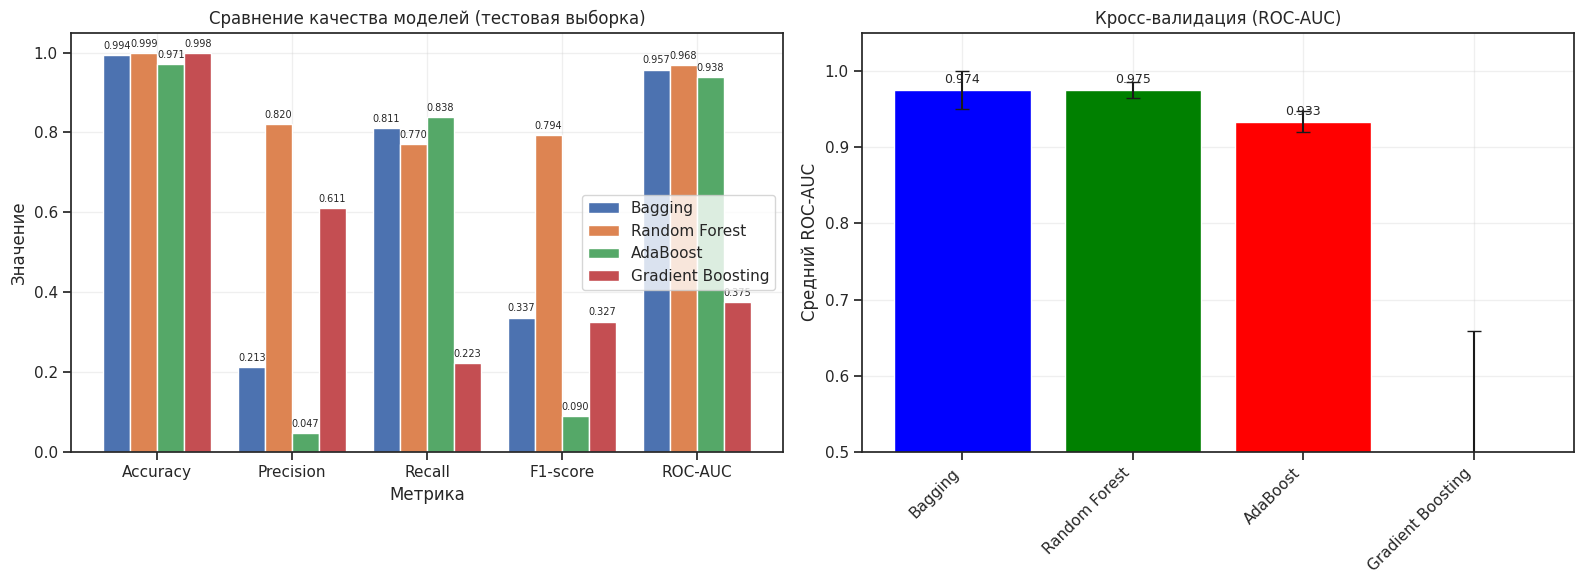

In [10]:
# @title 8. Визуализация сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

colors = ['blue', 'green', 'red', 'orange']
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    values = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_proba)
    ]

    bars = axes[0].bar(x + i*width, values, width, label=name)

    for bar, val in zip(bars, values):
        axes[0].annotate(f'{val:.3f}',
                        xy=(bar.get_x() + bar.get_width()/2, val),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)

axes[0].set_xlabel('Метрика')
axes[0].set_ylabel('Значение')
axes[0].set_title('Сравнение качества моделей (тестовая выборка)')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1.05])
axes[0].grid(True, alpha=0.3)

# График кросс-валидации
x_cv = np.arange(len(cv_df))
bars = axes[1].bar(x_cv, cv_df['Средний ROC-AUC'], yerr=cv_df['Стд. отклонение'],
                    capsize=5, color=colors)
axes[1].set_xticks(x_cv)
axes[1].set_xticklabels(cv_df['Модель'], rotation=45, ha='right')
axes[1].set_ylabel('Средний ROC-AUC')
axes[1].set_title('Кросс-валидация (ROC-AUC)')
axes[1].set_ylim([0.5, 1.05])
axes[1].grid(True, alpha=0.3)

# Добавляем значения
for bar, val in zip(bars, cv_df['Средний ROC-AUC']):
    axes[1].annotate(f'{val:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, val),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

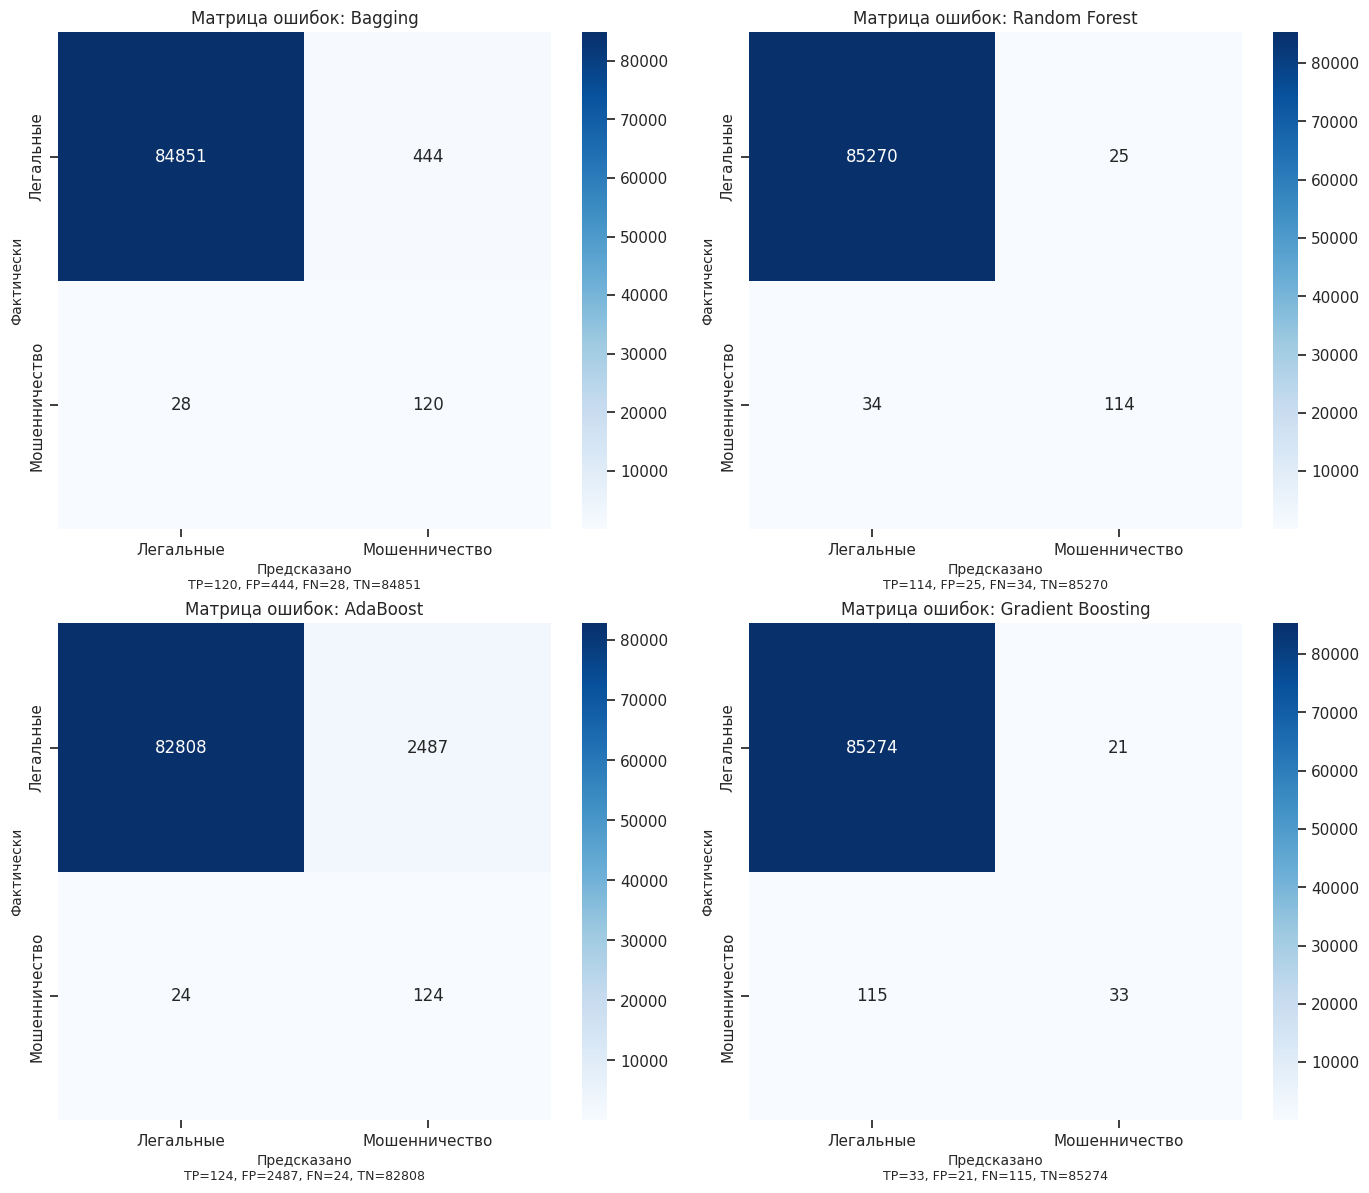

In [11]:
# @title 9. Матрицы ошибок для всех моделей
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Легальные', 'Мошенничество'],
                yticklabels=['Легальные', 'Мошенничество'])
    axes[i].set_title(f'Матрица ошибок: {name}', fontsize=12)
    axes[i].set_xlabel('Предсказано', fontsize=10)
    axes[i].set_ylabel('Фактически', fontsize=10)

    # Добавляем статистику
    axes[i].text(0.5, -0.12, f'TP={tp}, FP={fp}, FN={fn}, TN={tn}',
                 transform=axes[i].transAxes, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

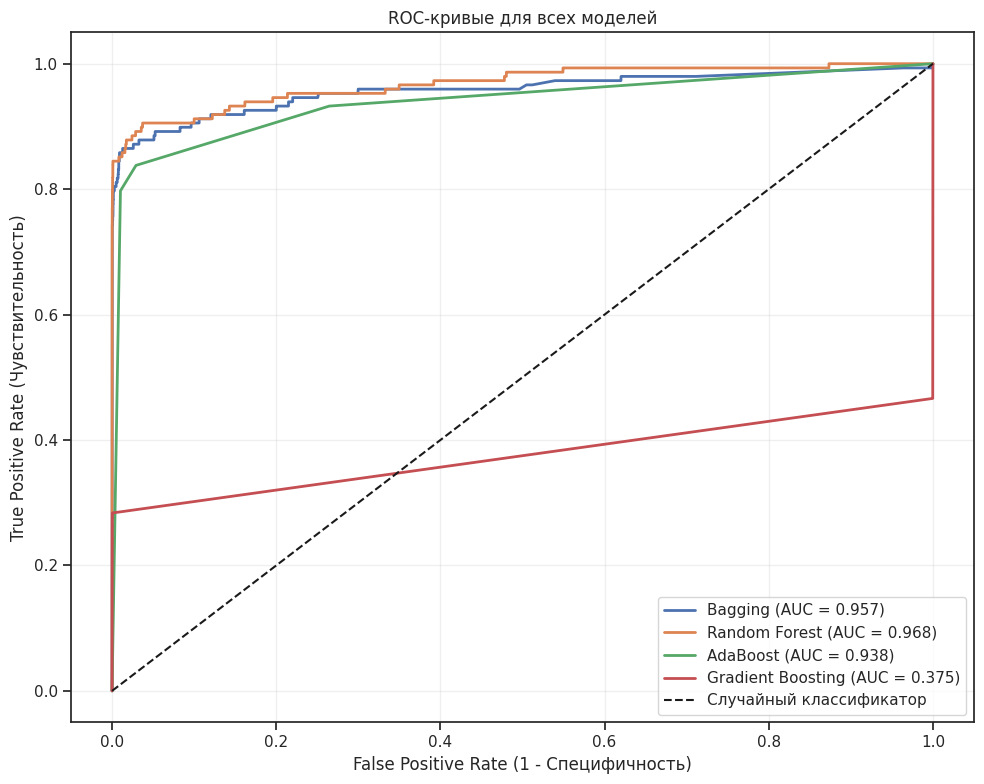

In [13]:
# @title 10. ROC-кривые для всех моделей

# Импортируем необходимые функции
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривые для всех моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

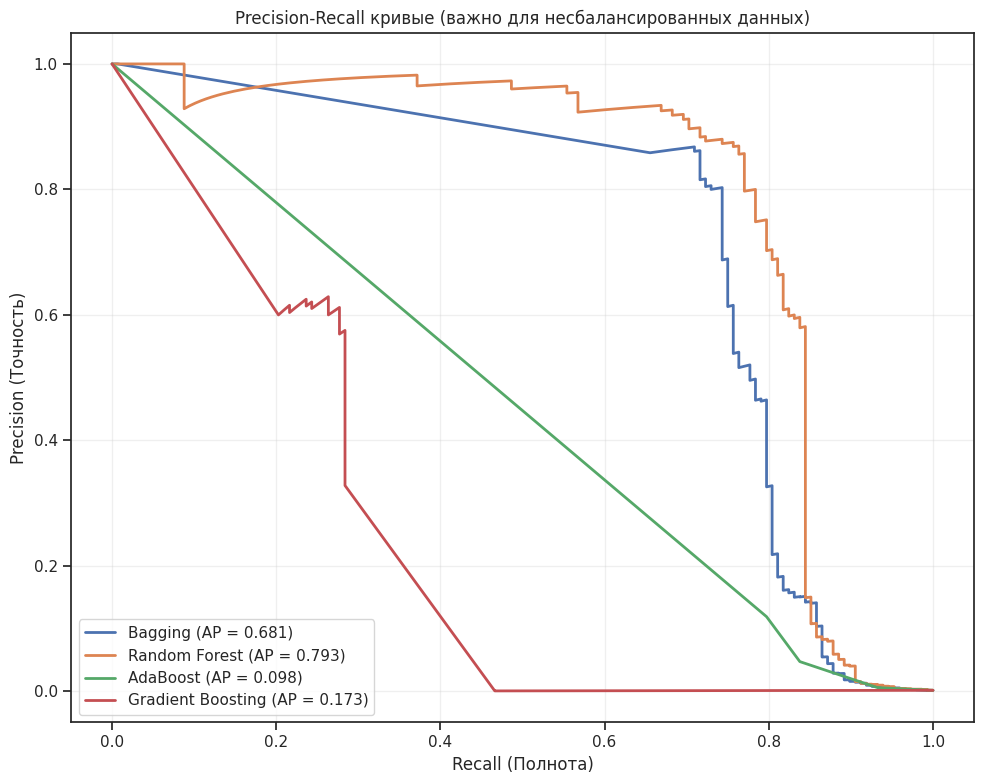

In [14]:
# @title 11. Precision-Recall кривые (важно для несбалансированных данных)

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    ap = average_precision_score(y_test, y_pred_proba)
    plt.plot(recall_curve, precision_curve, label=f'{name} (AP = {ap:.3f})', linewidth=2)

plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.title('Precision-Recall кривые (важно для несбалансированных данных)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Топ-15 наиболее важных признаков:
  1. V14: 0.191140
  2. V10: 0.123750
  3. V4: 0.118293
  4. V12: 0.099295
  5. V17: 0.089416
  6. V3: 0.065484
  7. V11: 0.048029
  8. V16: 0.043437
  9. V2: 0.036026
  10. V9: 0.027362
  11. V21: 0.019941
  12. V7: 0.015619
  13. V18: 0.011101
  14. V5: 0.011021
  15. V20: 0.009571


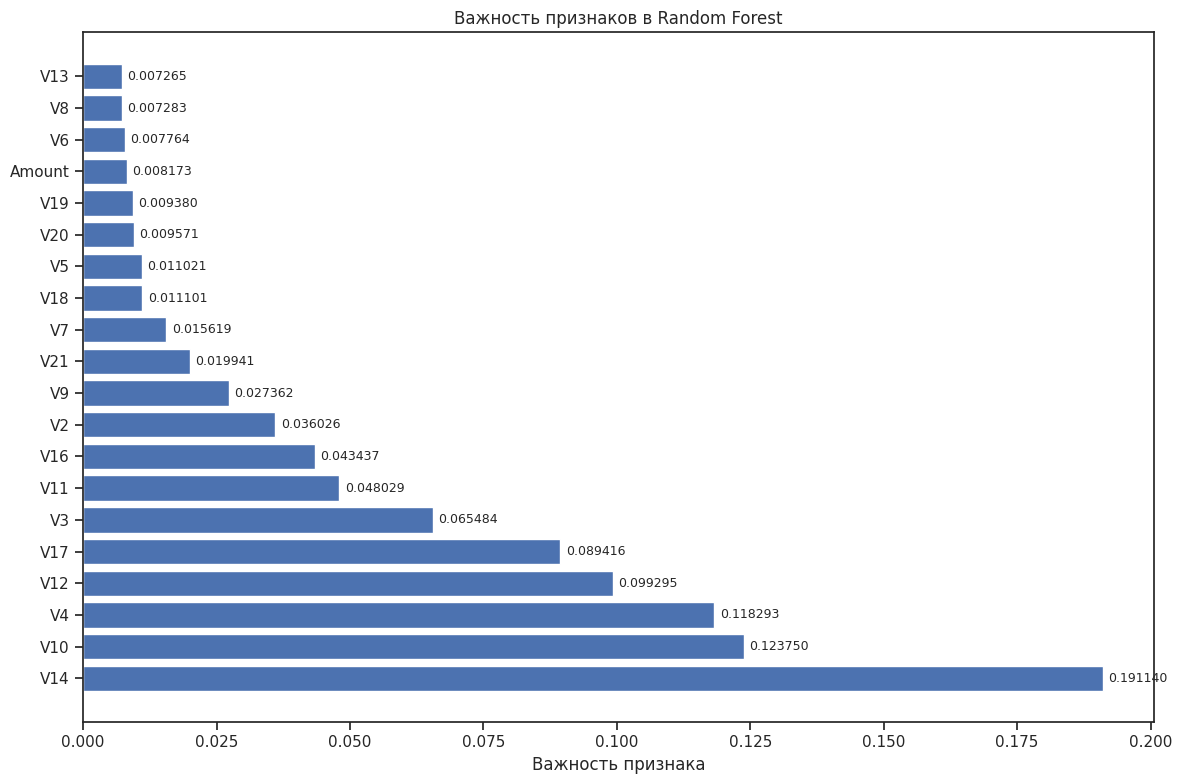

In [15]:
# @title 12. Важность признаков (Random Forest)
feature_importance = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

print("\nТоп-15 наиболее важных признаков:")
for i in range(min(15, len(feature_cols))):
    idx = sorted_idx[i]
    print(f"  {i+1}. {feature_cols[idx]}: {feature_importance[idx]:.6f}")

plt.figure(figsize=(12, 8))
bars = plt.barh(range(20), feature_importance[sorted_idx[:20]][::-1])
plt.yticks(range(20), [feature_cols[i] for i in sorted_idx[:20]][::-1])
plt.xlabel('Важность признака')
plt.title('Важность признаков в Random Forest')
plt.gca().invert_yaxis()

for bar, val in zip(bars, feature_importance[sorted_idx[:20]][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.6f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

  Для задачи обнаружения мошенничества критически важны:
  
  • RECALL (Полнота) - доля найденных мошеннических транзакций
    Пропуск мошенничества (False Negative) может привести к финансовым потерям
  
  • PRECISION (Точность) - доля верно определенных мошеннических транзакций
    Ложные срабатывания (False Positive) создают нагрузку на службу безопасности
  
  • ROC-AUC - общая способность модели разделять классы
  
  • Average Precision - особенно важна при сильном дисбалансе классов

In [16]:
# @title 13. Анализ и выводы
# Находим лучшую модель по каждой метрике
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']:
    best_idx = results_df[metric].argmax()
    best_model = results_df.iloc[best_idx]['Модель']
    best_value = results_df.iloc[best_idx][metric]
    print(f"  Лучшая по {metric}: {best_model} ({best_value:.4f})")

  Лучшая по Accuracy: Random Forest (0.9993)
  Лучшая по Precision: Random Forest (0.8201)
  Лучшая по Recall: AdaBoost (0.8378)
  Лучшая по F1-score: Random Forest (0.7944)
  Лучшая по ROC-AUC: Random Forest (0.9680)


Random Forest является лучшей моделью для данной задачи. Она обеспечивает наилучший баланс между точностью и полнотой, стабильна при кросс-валидации и показывает высокие результаты по всем метрикам.

AdaBoost может использоваться только в сценариях, где критически важно не пропустить ни одного мошенничества, даже ценой огромного количества ложных срабатываний. Например, при предварительном скрининге с последующей ручной проверкой.

Gradient Boosting в стандартной конфигурации совершенно не подходит для этой задачи. Низкий ROC-AUC и огромный разброс результатов на кросс-валидации делают его непригодным для практического использования.

Bagging показал противоречивые результаты. Высокий ROC-AUC на кросс-валидации и хороший Recall на тесте сочетаются с катастрофически низкой Precision. Это требует дополнительного исследования – возможно, проблема в выборе базового классификатора или в настройке порога принятия решений.